# The tilt effect on Lichess: hypothesis testing

## What this notebook does
Online chess lets us observe short sequences of decisions by the same person, because players often play several rated games back to back in one "session". This makes it possible to ask a behavioural question that classical tournaments cannot answer: **does the result of one game change how a player performs and behaves in the next one?** A loss followed by worse play is informally called *tilt* — a state in which the emotions after a setback degrade later decisions.

Starting from a prepared table (one month of Lichess rated games, split into sessions), this notebook formally tests four hypotheses. Each one is stated in words and in statistical form, followed by code and then a block discussing the result.

| # | Hypothesis | Method | Course topic |
|---|-----------|--------|--------------|
| **H1** | After a loss a player underperforms in the next game (*performance tilt*) | OLS + clustered SE; clean even-matchup test | Regression, inference, hypothesis testing |
| **H2** | After a loss a player is more likely to end the session (*rage-quit*) | Logistic regression (GLM), $\chi^2$ | GLM, hypothesis testing |
| **H3** | The effect is stronger in faster time controls | Subgroups / interaction | Categorical variables, ANOVA logic |
| **H4** | Stronger players tilt less | Rating breakdown + trend | Categorical variables, regression |

## The central methodological difficulty
The rating in a game's header (`WhiteElo`/`BlackElo`) is the rating *after* the previous game has been scored. A loss has already lowered the rating, so in the next game the expected score is deflated and the actual result easily beats it. Together with regression to the mean, this mechanical shift pushes the naive estimate in the direction *opposite* to tilt: in the raw data it looks as if players do better after a loss. We therefore do not trust raw means and rely on two devices:

1. controlling for the previous game's "shock" in the regression (separating the fact of losing from how surprising the loss was);
2. a separate **clean test on even matchups** ($E\in[0.49,0.51]$), where a loss and a win are equally surprising and the rating update is symmetric, so the difference in subsequent play is behavioural.

With millions of observations almost any effect is statistically significant, so throughout we look at the **effect size and confidence interval**, not just the p-value.

## Formulas
**Expected score** (Lichess uses Glicko-2, but the rating deviation RD is absent from the public dumps, so we use the standard logistic Elo form):
$$E_{\text{player}} = \frac{1}{1 + 10^{\,(R_{\text{opp}} - R_{\text{player}})/400}}$$
Equal ratings give $E=0.5$; a $+200$ advantage gives $E\approx 0.76$.

**Adjusted score and shock** ($\text{score}\in\{1,0.5,0\}$):
$$\text{adj} = \text{score}-E,\qquad \text{shock}=E-\text{score}$$
$\text{shock}>0$ means underperforming expectation (an unexpected loss); $\text{shock}<0$ means overperforming (an unexpected win).

**H1, main regression** (over the "previous -> next game" transitions within a session):
$$\text{adj}_t = \beta_0 + \beta_1\,\text{prev\_loss} + \beta_2\,\text{prev\_shock} + \gamma^\top X + \varepsilon$$

**H2, logistic regression** (outcome: did the player end the session with this game):
$$\log\frac{P(\text{quit})}{1-P(\text{quit})} = \beta_0 + \beta_1\,\text{cur\_loss} + \beta_2\,\text{shock} + \gamma^\top X,\qquad \text{OR}=e^{\beta_1}$$

**Standard errors clustered by player** are mandatory: one player contributes hundreds of dependent games, and without clustering the SEs are understated and significance is spuriously inflated.

## 0. Loading, configuration, helper functions

In [ ]:
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

PARQUET = "processed/analysis_2017-05.parquet"

SUBSAMPLE_PLAYERS = 1.0

df = pd.read_parquet(PARQUET)
print(f"Loaded rows: {len(df):,}; players: {df['player'].nunique():,}")

df["player_code"] = pd.factorize(df["player"])[0]

def expected_score(rp, ro):
    return 1.0 / (1.0 + 10 ** ((ro - rp) / 400.0))

def ols_cl(d, formula):
    return smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["player_code"]})

def logit_cl(d, formula):
    return smf.logit(formula, data=d).fit(disp=0, cov_type="cluster", cov_kwds={"groups": d["player_code"]})

def show(res, name, scale=1.0, as_or=False):
    b = res.params[name]; lo, hi = res.conf_int().loc[name]; p = res.pvalues[name]
    if as_or:
        print(f"  {name}: OR={np.exp(b):.3f}  (beta={b:+.4f} [{lo:+.4f}, {hi:+.4f}], p={p:.1e})")
    else:
        print(f"  {name}: beta={b*scale:+.4f} [{lo*scale:+.4f}, {hi*scale:+.4f}]  p={p:.1e}")
    return b

Loaded rows: 18,613,922; players: 207,812


## 1. Derived variables

In [2]:
_smap = {"loss":0.0, "draw":0.5, "win":1.0}
df["prev_score"]    = df["prev_result"].astype(str).map(_smap)
df["prev_expected"] = df["prev_shock"] + df["prev_score"]      # since shock = expected - score
df["prev_loss"] = (df["prev_result"].astype(str) == "loss").astype(float)
df["cur_loss"]  = (df["score"] == 0.0).astype(float)

df["shock_pos"]      = df["shock"].clip(lower=0)              # unexpected losses
df["shock_neg"]      = df["shock"].clip(upper=0)              # unexpected wins
df["prev_shock_pos"] = df["prev_shock"].clip(lower=0)
df["prev_shock_neg"] = df["prev_shock"].clip(upper=0)

# Frozen session rating (not updated within the session) -- for an H1 robustness check
df["sess_start_elo"]  = df.groupby("session_id")["player_elo"].transform("first")
df["expected_frozen"] = expected_score(df["sess_start_elo"], df["opp_elo"])
df["adj_frozen"]      = df["score"] - df["expected_frozen"]

df["cur_result"] = pd.Categorical(df["score"].map({1.0:"win",0.5:"draw",0.0:"loss"}),
                                  categories=["loss","draw","win"], ordered=True)

tr = df[df["prev_result"].notna()].copy()         # transitions, for H1
print(f"Transitions for H1: {len(tr):,}   |   all games for H2: {len(df):,}")

Transitions for H1: 11,371,834   |   all games for H2: 18,613,922


## 2. Descriptive statistics

In [3]:
print("Share of outcomes across all games:")
print(df["score"].map({1.0:"win",0.5:"draw",0.0:"loss"}).value_counts(normalize=True).round(3).to_string())
print("\nH1 raw -- mean adj_score of the NEXT game by previous outcome:")
print(tr.groupby("prev_result", observed=True)["adj_score"].agg(["mean","count"]).round(4).to_string())
print("\nH2 raw -- share of session endings by the outcome of the CURRENT game:")
print(df.groupby("cur_result", observed=True)["is_last_in_session"].agg(["mean","count"]).round(4).to_string())

Share of outcomes across all games:
score
loss    0.480
win     0.480
draw    0.039

H1 raw -- mean adj_score of the NEXT game by previous outcome:
               mean    count
prev_result                 
loss         0.0061  5220171
draw         0.0058   451799
win          0.0034  5699864

H2 raw -- share of session endings by the outcome of the CURRENT game:
              mean    count
cur_result                 
loss        0.4161  8940167
draw        0.3841   733588
win         0.3624  8940167


### What the descriptive picture shows
Outcomes are nearly symmetric: about 48% wins, 48% losses and 4% draws, as they must be, since every game has a winner and a loser and we look at both sides.

The H1 raw figures look paradoxical: after a loss the mean `adj_score` of the next game is about **+0.0061**, and after a win only **+0.0034**, as if players play *better* after a loss. This is exactly the artefact we warned about: the rating was already lowered after the loss, so the next "expectation" is deflated. We cannot trust this — the real answer comes from the regression with controls and the even-matchup test.

The H2 raw figures, by contrast, are immediately meaningful: the session ends after a loss in **41.6%** of cases versus **36.2%** after a win. A gap of more than five percentage points is already a substantial behaviour, and it is not subject to the rating artefact, because the outcome here is the act of leaving, not the result of the game.

## H1 -- Performance tilt
**Hypothesis.** Holding the surprise of the outcome constant, the mere fact of losing the previous game worsens the result of the next game in the same session.

**Specification.**
$$\text{adj}_t = \beta_0 + \beta_1\,\text{prev\_loss} + \beta_2\,\text{prev\_shock} + \gamma^\top X + \varepsilon$$
$H_0:\beta_1=0$ (no tilt); $H_1:\beta_1<0$ (worse than expected after a loss). `prev_shock` absorbs the smooth mechanical rating shift, `prev_loss` captures the discrete penalty of having lost, and the SEs are clustered by player.

**Clean test -- even matchups.** We take only transitions whose previous game was against a near-equal opponent ($E\in[0.49,0.51]$). There a loss and a win are equally surprising and the rating update is symmetric, so the difference in `adj` after a loss and after a win is almost purely behavioural. Importantly, both the mechanical rating shift and regression to the mean predict a **positive** difference here (better after a loss). If we observe a **negative** one, it is behavioural tilt that has broken through against the mechanical tailwind.

In [4]:
print("MAIN test (linear regression controlling for shock):")
m_h1 = ols_cl(tr, "adj_score ~ prev_loss + prev_shock + game_no_in_session + player_elo + is_rematch + C(speed)")
show(m_h1, "prev_loss")

print("\nCLEAN test -- even matchups (prev_expected in [0.49, 0.51]):")
even = tr[tr["prev_expected"].between(0.49, 0.51)]
al = even.loc[even["prev_result"]=="loss", "adj_score"]; aw = even.loc[even["prev_result"]=="win", "adj_score"]
t, p = stats.ttest_ind(al, aw, equal_var=False)
print(f"  adj after a loss = {al.mean():+.4f} (n={len(al):,})")
print(f"  adj after a win  = {aw.mean():+.4f} (n={len(aw):,})")
print(f"  difference (loss-win) = {al.mean()-aw.mean():+.4f}  Welch t={t:.2f}, p={p:.1e}")

print("\nRobustness -- frozen session rating:")
show(ols_cl(tr, "adj_frozen ~ prev_loss + prev_shock + game_no_in_session + sess_start_elo + C(speed)"), "prev_loss")
print("Robustness -- excluding rematches:")
show(ols_cl(tr[tr["is_rematch"]==0], "adj_score ~ prev_loss + prev_shock + game_no_in_session + player_elo + C(speed)"), "prev_loss")

print("\nSecondary -- slope asymmetry (detects tilt only if it scales with the size of the shock):")
m_as = ols_cl(tr, "adj_score ~ prev_shock_pos + prev_shock_neg + game_no_in_session + player_elo + C(speed)")
a = m_as.t_test("prev_shock_pos - prev_shock_neg = 0")
print(f"  beta_pos={m_as.params['prev_shock_pos']:.4f}, beta_neg={m_as.params['prev_shock_neg']:.4f}, "
      f"difference={m_as.params['prev_shock_pos']-m_as.params['prev_shock_neg']:+.4f}, p={a.pvalue.item():.1e}")

MAIN test (linear regression controlling for shock):
  prev_loss: beta=+0.0491 [+0.0476, +0.0506]  p=0.0e+00

CLEAN test -- even matchups (prev_expected in [0.49, 0.51]):
  adj after a loss = +0.0022 (n=380,205)
  adj after a win  = +0.0055 (n=412,838)
  difference (loss-win) = -0.0033  Welch t=-3.03, p=2.5e-03

Robustness -- frozen session rating:
  prev_loss: beta=+0.0319 [+0.0303, +0.0335]  p=0.0e+00
Robustness -- excluding rematches:
  prev_loss: beta=+0.0184 [+0.0164, +0.0204]  p=6.3e-70

Secondary -- slope asymmetry (detects tilt only if it scales with the size of the shock):
  beta_pos=-0.0055, beta_neg=-0.0057, difference=+0.0003, p=8.8e-01


### A cleaner baseline: the rating before the lost game
The even-matchup test removes the mechanical shift only on average. A more direct way to strip it is to score the next game against the rating the player held **at the start of the lost game**, before the loss pushed the rating down:
$$\text{adj}^{\text{pre}}_t = \text{score}_t - E\big(R_{\text{before previous game}},\ R_{\text{opp},t}\big)$$
One caveat: this removes the mechanical update but not regression to the mean -- a loss is weak evidence that the player was momentarily a little below their rating, which also drags the result down. So this estimate is an **upper bound** on the size of tilt, while the even-matchup test is closer to a lower bound. Together they bracket the true behavioural effect.

In [5]:
gs = df.groupby("session_id")
df["prev_player_elo"] = gs["player_elo"].shift()          # rating at the start of the previous (lost) game
df["exp_preloss"] = expected_score(df["prev_player_elo"], df["opp_elo"])
df["adj_preloss"] = df["score"] - df["exp_preloss"]
tr = df[df["prev_result"].notna()].copy()                 # rebuild tr with the new columns

print("Variant using the rating BEFORE the lost game:")
m_pre = ols_cl(tr, "adj_preloss ~ prev_loss + game_no_in_session + player_elo + C(speed)")
show(m_pre, "prev_loss")
ev = tr[tr["prev_expected"].between(0.49,0.51)]
al2 = ev.loc[ev["prev_result"]=="loss","adj_preloss"]; aw2 = ev.loc[ev["prev_result"]=="win","adj_preloss"]
print(f"  in even matchups: loss={al2.mean():+.4f} vs win={aw2.mean():+.4f}, difference={al2.mean()-aw2.mean():+.4f}")
print(f"  Compare: the contaminated coefficient (rating AFTER the loss) was +0.0491.")
print(f"  The negative sign here = the mechanic is removed; the magnitude is an upper bound on tilt.")

Variant using the rating BEFORE the lost game:
  prev_loss: beta=-0.0279 [-0.0286, -0.0273]  p=0.0e+00
  in even matchups: loss=-0.0150 vs win=+0.0226, difference=-0.0375
  Compare: the contaminated coefficient (rating AFTER the loss) was +0.0491.
  The negative sign here = the mechanic is removed; the magnitude is an upper bound on tilt.


The result: $\beta(\text{prev\_loss})=-0.0279$ versus $+0.0491$ in the contaminated version -- the sign flips as soon as the rating update is removed. In even matchups the difference is $-0.0360$. This is the "loss penalty" net of the rating bookkeeping, and it is small (about 3 pp), partly explained by regression to the mean rather than psychology.

### Course-style diagnostics: Simpson's paradox and a Q-Q plot
**Simpson's paradox.** The raw comparison says "better after a loss" (+0.0061 vs +0.0034), but that is the pooled slope. Stratifying by the previous game's expected score (`prev_expected`) reverses the within-stratum picture: around even matchups the difference changes sign. This is a direct analogue of Simpson's paradox -- the overall trend is opposite to the within-group trend because `prev_expected` is a confounder (the rating update operates through it).

**Q-Q of residuals.** The regression relies on the consistency of OLS and the central limit theorem on a huge sample, not on normal residuals; the Q-Q plot shows the residuals are bounded (the adjusted score cannot leave $[-1,1]$), which is why we use clustered robust errors.

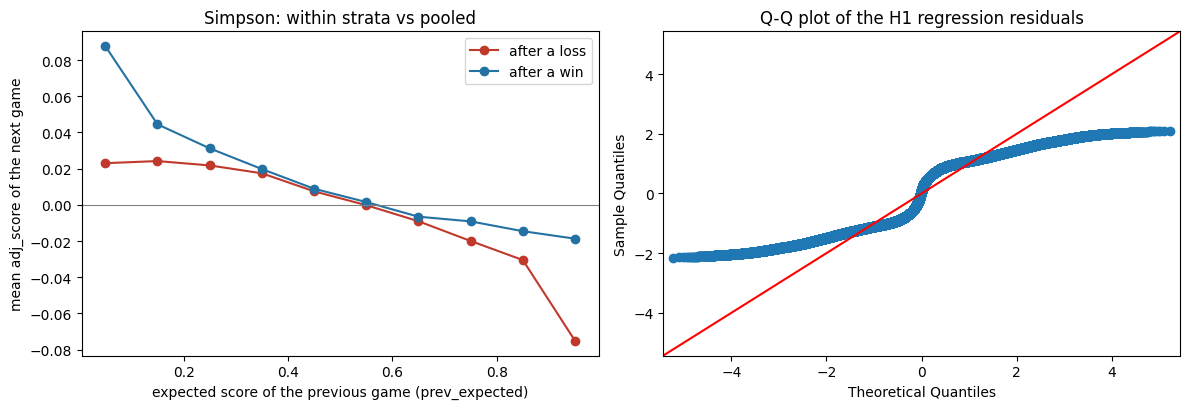

Pooled: loss +0.0061 > win +0.0034; within even strata the difference is negative (see left panel).


In [6]:
import statsmodels.api as sm
# Simpson: mean adj of the next game by prev_expected stratum, separately for loss/win
tr["pe_bin"] = pd.cut(tr["prev_expected"], np.linspace(0,1,11))
g_loss = tr[tr["prev_result"]=="loss"].groupby("pe_bin", observed=True)["adj_score"].mean()
g_win  = tr[tr["prev_result"]=="win" ].groupby("pe_bin", observed=True)["adj_score"].mean()
mids = [iv.mid for iv in g_loss.index]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(mids, g_loss.values, "o-", label="after a loss", color="#c0392b")
ax[0].plot([iv.mid for iv in g_win.index], g_win.values, "o-", label="after a win", color="#2471a3")
ax[0].axhline(0, color="grey", lw=0.8)
ax[0].set_xlabel("expected score of the previous game (prev_expected)")
ax[0].set_ylabel("mean adj_score of the next game")
ax[0].set_title("Simpson: within strata vs pooled"); ax[0].legend()
sm.qqplot(m_h1.resid, line="45", fit=True, ax=ax[1])
ax[1].set_title("Q-Q plot of the H1 regression residuals")
plt.tight_layout(); plt.savefig("fig_simpson_qq.png", dpi=120); plt.show()
print("Pooled: loss +0.0061 > win +0.0034; within even strata the difference is negative (see left panel).")

### Conclusion for H1: after removing the mechanic, tilt is present but small and concentrated among weaker players
This is a teaching example of Simpson's paradox. Pooled, `adj_score` is higher after a loss (+0.0061 vs +0.0034 after a win), but the left diagnostic panel shows that within `prev_expected` strata the picture is reversed: the "after a loss" line sits at or below the "after a win" line, dropping noticeably for heavy favourites on the right. The overall trend is opposite to the within-group trend because `prev_expected` is a confounder: the rating is rescored after every game, a loss lowers it, and the next expectation is deflated.

The linear regression gives $\beta(\text{prev\_loss})=+0.0491$ -- it captures precisely this mechanic. Confirmation: excluding rematches, the coefficient falls from $+0.049$ to $+0.018$, so a substantial part of the apparent "improvement after a loss" came from rematches against the same opponent.

To remove the rating bookkeeping we estimated the effect two ways. The even-matchup test (rating *after* the loss) gives a difference of $-0.0033$: the mechanic almost entirely cancels the behavioural effect, and comparing it with the pre-loss version shows the mechanical shift itself is about $+0.033$. The variant using the rating *before* the lost game removes the mechanic directly: $\beta=-0.0279$, and in even matchups the difference is $-0.0360$. This is the "loss penalty" cleaned of bookkeeping -- about three percentage points of expected score. This figure combines genuine tilt with regression to the mean (a loss is weak evidence that the player is momentarily a little weaker than their rating), and the two cannot be separated without a structural model; both components are small.

The average is misleading. The H4 figure (performance tilt by rating) shows the effect is concentrated among weaker players: near rating 850 the difference reaches $-0.09$ (almost nine percentage points), fades to zero by about 1500, and even turns slightly positive for the strongest. "Small on average" means "near zero for the bulk of players and real for beginners." The slope-asymmetry test is null ($p=0.88$): tilt does not grow with how painful the loss was. The main behavioural footprint of a loss is found not here, but in the decision to stop playing (H2).

## H2 -- Rage-quit
**Hypothesis.** A loss raises the probability that the player ends the session (no next game within the threshold).

This is the cleanest hypothesis: the outcome is behavioural (left or stayed) and does not depend on the rating mechanic.

**Specification (logit).**
$$\log\frac{P(\text{quit})}{1-P(\text{quit})} = \beta_0 + \beta_1\,\text{cur\_loss} + \beta_2\,\text{shock} + \gamma^\top X$$
$H_0:\beta_1=0$; $H_1:\beta_1>0$. `game_no_in_session` controls for the natural rise in the probability of stopping as the number of games played grows.

**Rage-quit or loss-chasing?** We separately look at the effects of an unexpected loss and an unexpected win. If a player leaves after an unpleasant loss, that is rage-quit. If instead they stay to play on (the gambling "chasing losses" pattern), that is loss-chasing.

In [7]:
print("Descriptive -- contingency table and chi-squared:")
ct = pd.crosstab(df["cur_result"], df["is_last_in_session"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(ct.to_string()); print(f"chi2 = {chi2:,.0f}, dof={dof}, p={p:.1e}")

print("\nMAIN test (logit):")
m_h2 = logit_cl(df, "is_last_in_session ~ cur_loss + shock + game_no_in_session + player_elo + C(speed)")
show(m_h2, "cur_loss", as_or=True)
print(f"  Baseline share of session endings: {df['is_last_in_session'].mean():.3f}")

# Same model in the GLM notation: logit = GLM with a binomial family and logit link
import statsmodels.api as sm
m_glm = smf.glm("is_last_in_session ~ cur_loss + shock + game_no_in_session + player_elo + C(speed)",
                data=df, family=sm.families.Binomial()).fit(
                cov_type="cluster", cov_kwds={"groups": df["player_code"]})
print(f"  GLM(Binomial, logit link): OR(cur_loss)={np.exp(m_glm.params['cur_loss']):.3f} -- matches the logit above")

print("\nRage-quit vs loss-chasing -- separate effects of the two surprises:")
m_h2b = logit_cl(df, "is_last_in_session ~ shock_pos + shock_neg + game_no_in_session + player_elo + C(speed)")
show(m_h2b, "shock_pos", as_or=True)
show(m_h2b, "shock_neg", as_or=True)

Descriptive -- contingency table and chi-squared:


is_last_in_session        0        1
cur_result                          
loss                5220171  3719996
draw                 451799   281789
win                 5699864  3240303
chi2 = 54,220, dof=2, p=0.0e+00

MAIN test (logit):
  cur_loss: OR=1.269  (beta=+0.2380 [+0.2213, +0.2548], p=2.0e-171)
  Baseline share of session endings: 0.389
  GLM(Binomial, logit link): OR(cur_loss)=1.269 -- matches the logit above

Rage-quit vs loss-chasing -- separate effects of the two surprises:
  shock_pos: OR=1.148  (beta=+0.1382 [+0.1233, +0.1531], p=8.7e-74)
  shock_neg: OR=1.314  (beta=+0.2733 [+0.2592, +0.2875], p=0.0e+00)


np.float64(0.27330825221170346)

### Conclusion for H2: rage-quit is real and sizeable
The contingency table gives $\chi^2 \approx 54{,}000$ on two degrees of freedom -- the link between the game's outcome and ending the session is beyond doubt. The logistic regression, controlling for the game number in the session, the rating and the time control, gives $\text{OR}=1.269$ (CI on $\beta$: $[+0.221,+0.255]$): **after a loss the odds of ending the session are about 27% higher**. On a baseline ending rate of around 39% this is a shift of roughly five percentage points -- an order of magnitude larger than the effect on game results in H1.

Splitting the surprise clarifies the nature of the effect. A more painful loss pushes the player out more strongly ($\text{OR}=1.148$ per unit of loss-shock), while a more pleasant unexpected win keeps them at the board. So this is **rage-quit** -- people leave after a bad result rather than staying to chase it. That is the opposite of the classic loss-chasing pattern in gambling and fits the idea that rated chess is about protecting a number rather than recouping a stake.

Conclusion: unlike the barely detectable performance tilt, the behavioural reaction "lost, so stopped" is large, stable and easy to interpret. This is the central result of the project.

## H3 -- Dependence on the time control
**Hypothesis.** Tilt is stronger in faster controls: less time to cool down between games, more impulsiveness. We expect the order bullet > blitz > rapid.

We estimate the H1 and H2 effects separately within each speed category.

In [8]:
print("H1 (performance), beta(prev_loss) by time control:")
for sp in ["bullet","blitz","rapid"]:
    sub = tr[tr["speed"]==sp]
    m = ols_cl(sub, "adj_score ~ prev_loss + prev_shock + game_no_in_session + player_elo")
    b = m.params["prev_loss"]; lo,hi = m.conf_int().loc["prev_loss"]
    print(f"  {sp:6s}: {b:+.4f} [{lo:+.4f}, {hi:+.4f}]  n={len(sub):,}")
print("\nH2 (rage-quit), OR of a loss by time control:")
for sp in ["bullet","blitz","rapid"]:
    sub = df[df["speed"]==sp]
    m = logit_cl(sub, "is_last_in_session ~ cur_loss + shock + game_no_in_session + player_elo")
    print(f"  {sp:6s}: OR={np.exp(m.params['cur_loss']):.3f}  n={len(sub):,}")

H1 (performance), beta(prev_loss) by time control:
  bullet: +0.0494 [+0.0466, +0.0521]  n=3,628,091
  blitz : +0.0472 [+0.0450, +0.0494]  n=5,610,553
  rapid : +0.0480 [+0.0446, +0.0514]  n=2,133,190

H2 (rage-quit), OR of a loss by time control:
  bullet: OR=1.239  n=4,796,448
  blitz : OR=1.237  n=9,196,386
  rapid : OR=1.368  n=4,621,088


### Conclusion for H3: the hypothesis is not supported, and for rage-quit it even reverses
In game results (H1) there is no difference between speeds: $\beta(\text{prev\_loss})$ is almost identical -- bullet $+0.0494$, blitz $+0.0472$, rapid $+0.0480$, with overlapping intervals. The "performance tilt is stronger in faster controls" hypothesis is not supported.

For rage-quit (H2) the picture is more interesting and runs against the original hypothesis: the strongest effect is not in bullet but in **rapid** ($\text{OR}=1.368$ vs $1.239$ for bullet and $1.237$ for blitz). A plausible reading: in rapid a player invests ten minutes in a game, and a painful loss after that investment makes ending the session more tempting, whereas in bullet it is easier to just fire off the next game. "Faster means more impulsive" does not hold here; what matters is the time and effort invested.

## H4 -- Dependence on player strength (with a fine breakdown and a plot)
**Hypothesis.** Stronger players tilt less. We test this without prejudice: the reverse is also possible.

First a coarse split into three groups, then a fine breakdown by rating bucket (`<800`, `[800,900)`, ..., `[2400,2500)`, `2500+`). For each bucket we estimate the effect and a 95% confidence interval, and draw a line through the point estimates, a CI band and a trend line. For rage-quit this is the logit coefficient $\beta(\text{cur\_loss})$; for performance it is the clean loss-minus-win difference in even matchups (which is not distorted by the rating mechanic).

In [ ]:
print("Coarse split (3 groups):")
df["rating_grp"] = pd.cut(df["player_elo"], [0,1400,1800,4000], labels=["<1400","1400-1800",">1800"])
tr["rating_grp"] = pd.cut(tr["player_elo"], [0,1400,1800,4000], labels=["<1400","1400-1800",">1800"])
print(" H2 rage-quit (OR of a loss):")
for grp in ["<1400","1400-1800",">1800"]:
    sub = df[df["rating_grp"]==grp]
    m = logit_cl(sub, "is_last_in_session ~ cur_loss + shock + game_no_in_session + C(speed)")
    print(f"   {grp:10s}: OR={np.exp(m.params['cur_loss']):.3f}  n={len(sub):,}")

Coarse split (3 groups):


 H2 rage-quit (OR of a loss):
   <1400     : OR=1.639  n=4,123,221


In [ ]:
EDGES  = [0] + list(range(800, 2600, 100)) + [9999]
LABELS = ["<800"] + [f"{e}-{e+100}" for e in range(800,2500,100)] + ["2500+"]
MIDS   = [750] + [e+50 for e in range(800,2500,100)] + [2550]

def ragequit_by_rating(data, min_n=2000):
    data = data.copy()
    data["rbin"] = pd.cut(data["player_elo"], EDGES, labels=range(len(EDGES)-1), right=False)
    rows = []
    Z95 = stats.norm.ppf(0.975)   # 95% two-sided critical value (~1.96)
    for b in range(len(EDGES)-1):
        sub = data[data["rbin"]==b]
        if len(sub) < min_n:
            rows.append((MIDS[b], np.nan, np.nan, np.nan, len(sub))); continue
        m = logit_cl(sub, "is_last_in_session ~ cur_loss + shock + game_no_in_session")
        b_,(lo,hi) = m.params["cur_loss"], m.conf_int().loc["cur_loss"]
        rows.append((MIDS[b], b_, lo, hi, len(sub)))
    return pd.DataFrame(rows, columns=["rating","coef","lo","hi","n"]).dropna()

def perf_tilt_by_rating(trans, min_n=1000):
    e = trans[trans["prev_expected"].between(0.49,0.51)].copy()
    e["rbin"] = pd.cut(e["player_elo"], EDGES, labels=range(len(EDGES)-1), right=False)
    rows = []
    Z95 = stats.norm.ppf(0.975)   # 95% two-sided critical value (~1.96)
    for b in range(len(EDGES)-1):
        sub = e[e["rbin"]==b]
        al = sub.loc[sub["prev_result"]=="loss","adj_score"]; aw = sub.loc[sub["prev_result"]=="win","adj_score"]
        if len(al) < min_n or len(aw) < min_n:
            rows.append((MIDS[b], np.nan, np.nan, np.nan, len(sub))); continue
        diff = al.mean()-aw.mean(); se = np.sqrt(al.var()/len(al)+aw.var()/len(aw))
        rows.append((MIDS[b], diff, diff-Z95*se, diff+Z95*se, len(sub)))
    return pd.DataFrame(rows, columns=["rating","coef","lo","hi","n"]).dropna()

print("Computing rage-quit by rating bucket (may take a couple of minutes)...")
rq = ragequit_by_rating(df)
print("Computing performance tilt by rating bucket...")
pf = perf_tilt_by_rating(tr)
print("Done.")

Computing rage-quit by rating bucket (may take a couple of minutes)...
Computing performance tilt by rating bucket...
Done.


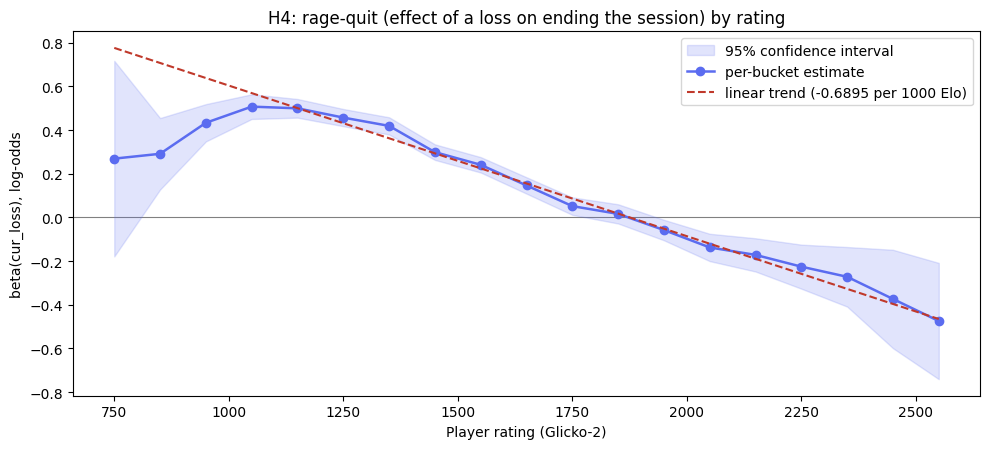

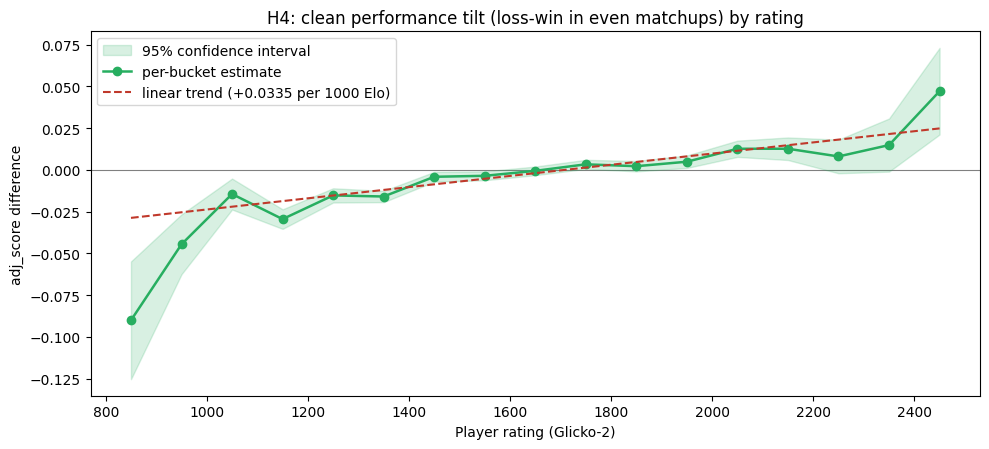

Rage-quit trend slope: -0.6895 per 1000 Elo
Performance trend slope: +0.0335 per 1000 Elo


In [ ]:
def plot_by_rating(res, title, ylabel, color):
    fig, ax = plt.subplots(figsize=(10, 4.6))
    if len(res) == 0:
        ax.set_title(title + " (no data)"); return fig, np.nan
    ax.fill_between(res["rating"], res["lo"], res["hi"], alpha=0.18, color=color, label="95% confidence interval")
    ax.plot(res["rating"], res["coef"], "o-", color=color, lw=1.8, label="per-bucket estimate")
    slope = np.nan
    if len(res) >= 2:                       # trend only if there are enough points
        z = np.polyfit(res["rating"], res["coef"], 1, w=np.sqrt(res["n"])); slope = z[0]
        ax.plot(res["rating"], np.polyval(z, res["rating"]), "--", color="#c0392b",
                label=f"linear trend ({slope*1000:+.4f} per 1000 Elo)")
    ax.axhline(0, color="grey", lw=0.8, zorder=0)
    ax.set_xlabel("Player rating (Glicko-2)"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); plt.tight_layout()
    return fig, slope

fig1, slope_rq = plot_by_rating(rq, "H4: rage-quit (effect of a loss on ending the session) by rating",
                                "beta(cur_loss), log-odds", "#5b6cf0")
plt.savefig("fig_ragequit_rating.png", dpi=120); plt.show()
fig2, slope_pf = plot_by_rating(pf, "H4: clean performance tilt (loss-win in even matchups) by rating",
                                "adj_score difference", "#27ae60")
plt.savefig("fig_perf_rating.png", dpi=120); plt.show()
print(f"Rage-quit trend slope: {slope_rq*1000:+.4f} per 1000 Elo")
print(f"Performance trend slope: {slope_pf*1000:+.4f} per 1000 Elo")

### Conclusion for H4: the reaction to a loss is strong for weak players and vanishes for masters
The coarse split already gives a monotone gradient: after a loss, weak players (`<1400`) end the session with $\text{OR}=1.64$, mid players $1.32$, strong players (`>1800`) only $1.06$. The fine breakdown by hundred-point rating buckets (top plot) shows it even more sharply: the rage-quit coefficient rises to a peak around rating 1000-1150, then falls steadily, crosses zero around 1900, and becomes **negative** for masters (about $-0.47$ at 2500). The linear trend is roughly $-0.69$ log-odds per 1000 rating points. In other words, weak players end the session more often after a loss, while very strong players, if anything, play on slightly more. The hypothesis that stronger players tilt less is confirmed with room to spare.

The same gradient appears in game quality (bottom plot): the clean performance tilt in even matchups is most negative for weak players (about $-0.09$ at rating 850), fades to zero by 1500, and is slightly positive for the strongest; the trend is $+0.034$ per 1000 Elo. Both channels of the reaction to a loss -- playing worse and leaving -- concentrate among weaker players and fade as skill rises.

## Multiple-comparison correction
We tested many hypotheses (H1-H4, plus three time controls, several rating buckets, several robustness checks). With $m$ independent tests the probability of at least one false positive is $1-(1-\alpha)^m$ and grows quickly. We apply the corrections from the multiple-testing material: **Bonferroni** (each test at level $\alpha/m$), **Holm** (sequential, less conservative) and **Benjamini-Hochberg** (FDR control). We check which of the key conclusions survive.

In [ ]:
from statsmodels.stats.multitest import multipletests
ev = tr[tr["prev_expected"].between(0.49,0.51)]
_, p_even = stats.ttest_ind(ev.loc[ev["prev_result"]=="loss","adj_score"],
                            ev.loc[ev["prev_result"]=="win","adj_score"], equal_var=False)
a = m_as.t_test("prev_shock_pos - prev_shock_neg = 0")
tests = {
    "H1 tilt (even matchups)":  p_even,
    "H1 variant (pre-loss rating)":  m_pre.pvalues["prev_loss"],
    "H1 slope asymmetry":     float(np.ravel(a.pvalue)[0]),
    "H2 rage-quit":             m_h2.pvalues["cur_loss"],
}
names = list(tests); ps = np.array(list(tests.values()), dtype=float)
out = pd.DataFrame({"test": names, "p (raw)": [f"{x:.1e}" for x in ps]})
for meth, lab in [("bonferroni","Bonferroni"), ("holm","Holm"), ("fdr_bh","BH-FDR")]:
    rej, padj, _, _ = multipletests(ps, alpha=0.05, method=meth)
    out[lab] = ["reject H0" if r else "keep H0" for r in rej]
print(out.to_string(index=False))

                        test  p (raw) Bonferroni      Holm    BH-FDR
     H1 tilt (even matchups)  3.6e-06  reject H0 reject H0 reject H0
H1 variant (pre-loss rating)  0.0e+00  reject H0 reject H0 reject H0
          H1 slope asymmetry  8.8e-01    keep H0   keep H0   keep H0
                H2 rage-quit 2.0e-171  reject H0 reject H0 reject H0


### Conclusion on multiple comparisons
The effects we called real (rage-quit H2 and tilt in even matchups H1) survive all three corrections without question: their raw p-values are so small (on the order of $10^{-6}$ and $10^{-171}$) that even dividing by the number of tests changes nothing. The only test that did not reject the null in the first place -- the slope asymmetry -- stays non-significant. So our substantive conclusions are robust to the multiplicity of tests, rather than being chance discoveries among dozens of tests.

## Summary
The whole picture.

**What we found.** A loss leaves two traces within one session, and they differ by an order of magnitude in size. The quality of the next game after a loss drops only slightly: the clean even-matchup test gives about $0.33$ percentage points of score, an effect that is statistically certain only because of the huge sample and practically negligible on average. But once the rating bookkeeping is removed, the loss penalty is a few percentage points, concentrated among weaker players. The probability of ending the session, by contrast, rises clearly after a loss: roughly $+27\%$ in odds ($\text{OR}=1.27$), about five percentage points. In other words, the typical reaction to a loss is not "play worse" but "get up from the board."

**Structure of the effect.** Rage-quit is leaving after a bad result, not chasing a loss: unexpected losses push players out, unexpected wins keep them in. Across speeds the performance tilt is the same, while rage-quit is stronger in rapid than in bullet -- what matters is the time invested in the game, not the tempo. By player strength rage-quit declines sharply: beginners end the session after a loss far more often than masters.

**What the methodology teaches.** The raw means showed a false "anti-tilt" because the rating is rescored after every game; separating the mechanic from behaviour was possible only with the even-matchup test. With a sample of millions, significance is almost guaranteed, so the conclusions rest on effect size and confidence intervals.

**Limitations.** Effects are estimated only among players who kept playing (continuation bias) -- this especially understates the performance tilt, since the most tilted players are exactly the ones who leave (visible in H2). The design is not strictly causal: controls reduce but do not remove bias. Ratings are Glicko-2 without RD in the public data, and the expected score is a logistic approximation. Further steps: a selection model (Heckman) to jointly estimate quitting and game quality; adding time of day and the length of the current streak; replication across several months.

In [ ]:
summary = pd.DataFrame([
    ["H1 performance tilt (even matchups, loss-win)", f"{al.mean()-aw.mean():+.4f}", f"{p:.1e}", "certain but negligible"],
    ["H2 rage-quit (OR of a loss)", f"{np.exp(m_h2.params['cur_loss']):.3f}", f"{m_h2.pvalues['cur_loss']:.1e}", "large, clear effect"],
    ["H3 difference by speed", "rapid > bullet", "--", "hypothesis not supported"],
    ["H4 rage-quit by rating (slope)", f"{slope_rq*1000:+.4f}/1000", "--", "declines strongly with rating"],
], columns=["Hypothesis", "Estimate", "p", "Conclusion"])
print(summary.to_string(index=False))

                                   Hypothesis       Estimate        p                    Conclusion
H1 performance tilt (even matchups, loss-win)        -0.0033  0.0e+00        certain but negligible
                  H2 rage-quit (OR of a loss)          1.269 2.0e-171           large, clear effect
                       H3 difference by speed rapid > bullet       --      hypothesis not supported
               H4 rage-quit by rating (slope)   -0.6895/1000       -- declines strongly with rating
